In [1]:
pip install qiskit-nature pyscf qiskit==1.4.5 qiskit-ibm-runtime qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of qiskit-ibm-runtime to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService, Estimator

service = QiskitRuntimeService(channel="ibm_quantum_platform",token="o0HHHmjs4XqpE1a8XStoNA1St_k1lzzoYx1LYxBgxnh-")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False))


qiskit_runtime_service._discover_account:WARNING:2026-03-04 05:51:36,341: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-04 05:51:40,088: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-04 05:51:40,089: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


In [7]:
backend = service.least_busy(operational=True, simulator=False)
print(f"Backend = {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-03-04 05:55:43,419: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-04 05:55:47,405: Using instance: open-instance, plan: open


Backend = ibm_fez


In [10]:
estimator = Estimator(mode=backend)
estimator.options.default_shots = 2048

In [11]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit



from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()




# # We will start by using a local simulator
# from qiskit_aer import AerSimulator

# # Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
# from qiskit.primitives import BackendEstimatorV2

# # generate a simulator that mimics the real quantum system
# backend_sim = AerSimulator.from_backend(backend)
# estimator = BackendEstimatorV2(backend=backend_sim)


from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

num_spatial_orbitals = 2
num_particles = (1, 1)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper,
    ),
)
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
ansatz_isa = pm.run(ansatz)

from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []


# Bond lengths in Angstrom
bond_lengths = np.array([0.75])

for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy



    vqe_solver = VQE(estimator, ansatz, COBYLA())
    vqe_solver.initial_point = [0.0] * ansatz.num_parameters
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz_isa.layout)

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, [H], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
        return energy


    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 30, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    ground_state_energy = energy + nuclear_repulsion


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)



# Create table
df = pd.DataFrame({
    "Bond Length (Å)": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies
})
print(df)


ERROR:stevedore.extension:Could not load 'ibm_backend': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_and_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_circuits': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qi

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 30   Least value of F = -1.6135785058490644
The corresponding X is:
[ 0.05622898  0.06193514 -0.13353302]

   Bond Length (Å)                                            Results  \
0             0.75  {'x': [0.05622898238231749, 0.0619351373444218...   

   Ground State Energy (Hartree)     Time (s)  \
0                      -0.908009  1897.637656   

   Nuclear Repulsion Energy (Hartree)  Electronic Energies (Hartree)  
0                             0.70557                      -1.613579  


ansatz depth = 310


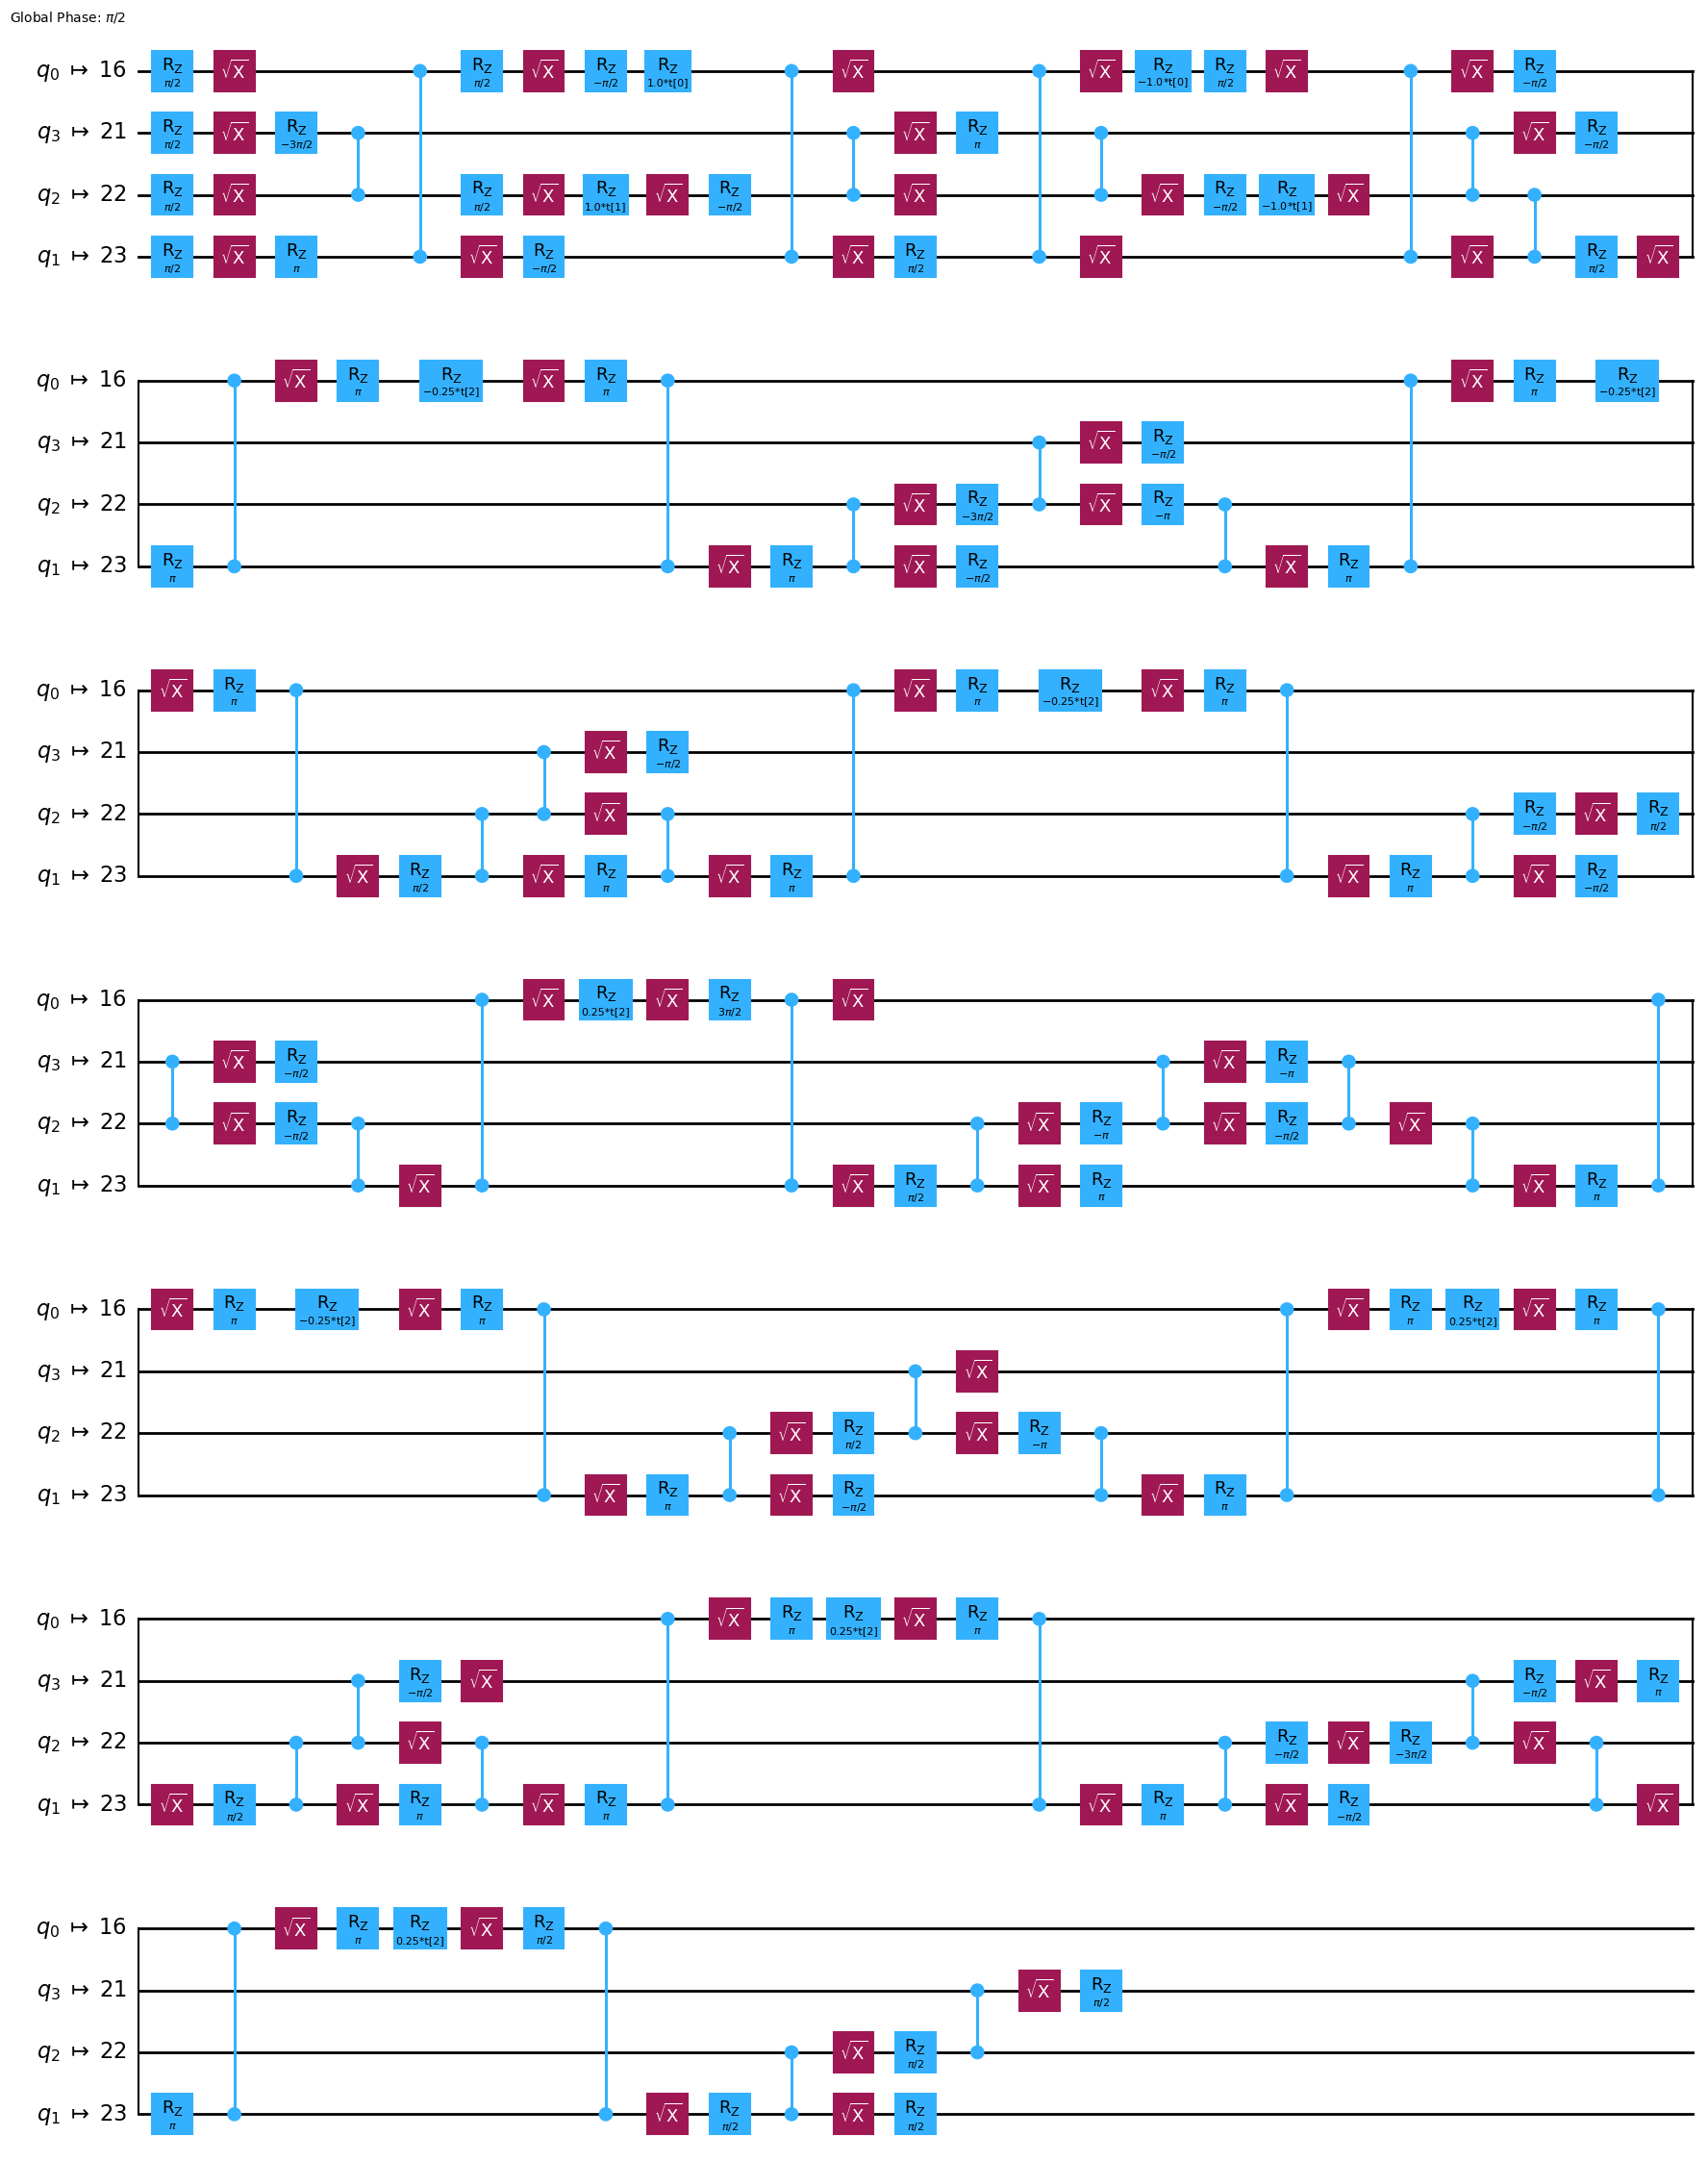

In [18]:
print(f"ansatz depth = {ansatz_isa.decompose().depth()}")
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [17]:
# Saving Data
import os
import pickle
import json
from qiskit import qpy
from google.colab import drive

# Mount Google Drive (safe if already mounted)
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/vqe_experiment"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 1. Save optimizer result
# -----------------------------
with open(os.path.join(save_dir, "optimizer_result.pkl"), "wb") as f:
    pickle.dump(result, f)

# -----------------------------
# 2. Save optimized parameters
# -----------------------------
optimal_parameters = result.x
with open(os.path.join(save_dir, "optimal_parameters.pkl"), "wb") as f:
    pickle.dump(optimal_parameters, f)

# -----------------------------
# 3. Save Hamiltonian
# -----------------------------
with open(os.path.join(save_dir, "hamiltonian.pkl"), "wb") as f:
    pickle.dump(hamiltonian_isa, f)

# -----------------------------
# 4. Save Ansatz Circuit
# -----------------------------
with open(os.path.join(save_dir, "ansatz.qpy"), "wb") as f:
    qpy.dump(ansatz_isa, f)

# -----------------------------
# 5. Save backend information
# -----------------------------
backend_info = {
    "backend_name": backend.name,
    "num_qubits": backend.num_qubits,
    "version": backend.version,
}

with open(os.path.join(save_dir, "backend_info.json"), "w") as f:
    json.dump(backend_info, f, indent=4)

# -----------------------------
# 6. Save experiment metadata
# -----------------------------
experiment_metadata = {
    "bond_length": float(r),
    "basis": "sto3g",
    "shots": estimator.options.default_shots,
    "optimizer": "COBYLA",
    "maxiter": 40,
    "energy": float(energy),
    "ground_state_energy": float(ground_state_energy),
    "nuclear_repulsion_energy": float(nuclear_repulsion),
    "iterations": result.nfev,
    "optimizer_success": result.success,
    "backend": backend.name
}

with open(os.path.join(save_dir, "experiment_metadata.json"), "w") as f:
    json.dump(experiment_metadata, f, indent=4)

# -----------------------------
# 7. Save DataFrame results
# -----------------------------
df.to_pickle(os.path.join(save_dir, "results_dataframe.pkl"))
df.to_csv(os.path.join(save_dir, "results_dataframe.csv"), index=False)

# -----------------------------
# 8. Save additional circuit info
# -----------------------------
circuit_info = {
    "num_qubits": ansatz_isa.num_qubits,
    "num_parameters": ansatz_isa.num_parameters,
    "circuit_depth": ansatz_isa.depth()
}

with open(os.path.join(save_dir, "circuit_info.json"), "w") as f:
    json.dump(circuit_info, f, indent=4)

print("✅ All VQE experiment data saved in:")
print(save_dir)

# Optional: list files saved
print("\nSaved files:")
print(os.listdir(save_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All VQE experiment data saved in:
/content/drive/MyDrive/vqe_experiment

Saved files:
['optimizer_result.pkl', 'optimal_parameters.pkl', 'hamiltonian.pkl', 'ansatz.qpy', 'backend_info.json', 'experiment_metadata.json', 'results_dataframe.pkl', 'results_dataframe.csv', 'circuit_info.json']
